# Case study 4: 40 DOF = 10 x 4-DOF

Ten 4-DOF subsystems with the four filter types cycled through, nine unknown parameters (stiffnesses, dampings and a mass), and a force on every mass. The largest case: 80 dynamic states, solved with 10 local filters of 8-10 states each.

The chain has non-uniform masses, stiffnesses and dampings, random forces act on
every mass, and messages are mean interface forces exchanged with the
**jacobi** schedule. The measurement covariance is inflated
10x to account for the message error (see [Concepts](../concepts.md)).

The paper-length horizon is 20 s at 1 ms; set `PCI_T` to shorten it. Set
`RUN_CENTRAL = True` to also run a single UKF on the full augmented state for
comparison.

In [1]:
import os

from _support import build, centralized, compare_with_yaml, print_design, report

N_DOF = 40
PARTITION = [[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12], [13, 14, 15, 16], [17, 18, 19, 20], [21, 22, 23, 24], [25, 26, 27, 28], [29, 30, 31, 32], [33, 34, 35, 36], [37, 38, 39, 40]]
NAMES = ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10']
SCHEDULE = "jacobi"
DT, T = 1e-3, float(os.environ.get("PCI_T", 20.0))
R_INFLATION = 10.0     # R = (10 x sensor noise)^2, needed with mean-only messages
RUN_CENTRAL = False

## Design: one line per subsystem

Filter, integrator, sensors with their noise standard deviation, and the unknowns as
a fraction of the true value used for the initial guess.

In [2]:
DESIGN = [
    dict(filter='kf', integrator='heun', sensors={'a2': 0.005, 'a4': 0.005}, unknowns={}),  # grounded, accelerations only
    dict(filter='ukf', integrator='heun', sensors={'x6': 0.001, 'a8': 0.01}, unknowns={'k7': 0.7}),
    dict(filter='ckf', integrator='heun', sensors={'x11': 0.001, 'a12': 0.005}, unknowns={'k10': 0.6, 'c10': 1.5}),
    dict(filter='kf', integrator='heun', sensors={'x14': 0.0001, 'x16': 0.0001}, unknowns={}),
    dict(filter='ukf', integrator='rk4', sensors={'x19': 0.001}, unknowns={'k18': 1.3}),
    dict(filter='ckf', integrator='heun', sensors={'x22': 0.001, 'a24': 0.01}, unknowns={'k23': 0.7}),
    dict(filter='ekf', integrator='heun', sensors={'x26': 0.0001, 'a28': 0.005}, unknowns={'m27': 0.8}),
    dict(filter='kf', integrator='euler', sensors={'a30': 0.005, 'x32': 0.0001}, unknowns={}),
    dict(filter='ukf', integrator='heun', sensors={'x35': 0.001, 'a36': 0.01}, unknowns={'k34': 0.6, 'c34': 0.6}),
    dict(filter='ckf', integrator='heun', sensors={'x40': 0.001}, unknowns={'k39': 1.4}),
]
LOADS = {d: {"type": "random", "std": 400.0, "seed": 40 + d} for d in range(1, N_DOF + 1)}

## Physical system, synthetic data, decomposition

In [3]:
chain, truth_dict, data, system, unknowns, sensors, noise = build(N_DOF, PARTITION, NAMES, DESIGN, LOADS, DT, T, SCHEDULE, R_INFLATION)
print_design("40 DOF = 10 x 4-DOF", NAMES, PARTITION, DESIGN, DT, T, SCHEDULE, R_INFLATION)

40 DOF = 10 x 4-DOF   schedule = jacobi   dt = 0.001   T = 20.0 s   steps = 20000   R inflation = 10x
----------------------------------------------------------------------------------------------------
subsystem DOFs              filter  integrator  task                      sensors (noise std)                     
S1        [1, 2, 3, 4]      kf      heun        state estimation          a2 (0.005), a4 (0.005)                  
S2        [5, 6, 7, 8]      ukf     heun        joint: k7                 x6 (0.001), a8 (0.01)                   
S3        [9, 10, 11, 12]   ckf     heun        joint: k10, c10           x11 (0.001), a12 (0.005)                
S4        [13, 14, 15, 16]  kf      heun        state estimation          x14 (0.0001), x16 (0.0001)              
S5        [17, 18, 19, 20]  ukf     rk4         joint: k18                x19 (0.001)                             
S6        [21, 22, 23, 24]  ckf     heun        joint: k23                x22 (0.001), a24 (0.01)          

## Distributed estimation

In [4]:
res = system.estimate(data, loads={f"f{d}": v for d, v in LOADS.items()}, dt=DT, T=T, truth=truth_dict)
report(res, chain.parameters, unknowns, NAMES, PARTITION, T)

Distributed run time: 39.9 s (sequential; ~4.0 s with one core per subsystem)

parameter       true   initial       final  error %  post. std
k7           53988.7   37792.1     51895.5    -3.88        449
k10          55252.1   33151.3     53597.6    -2.99        368
c10            218.0     327.0       389.0   +78.43       29.4
k18          37663.6   48962.7     39840.2    +5.78    1.6e+03
k23          37518.8   26263.2     36708.7    -2.16        360
m27            549.9     439.9       547.7    -0.40       2.97
k34          52699.8   31619.9     52098.0    -1.14        472
c34            361.7     217.0       408.3   +12.87       35.1
k39          55262.2   77367.1     57539.6    +4.12   1.71e+03

subsystem   disp. NRMSE (2nd half)   vel. NRMSE (2nd half)
S1                          0.285%                  0.432%
S2                          0.172%                  0.667%
S3                          0.194%                  0.820%
S4                          0.082%                  0.

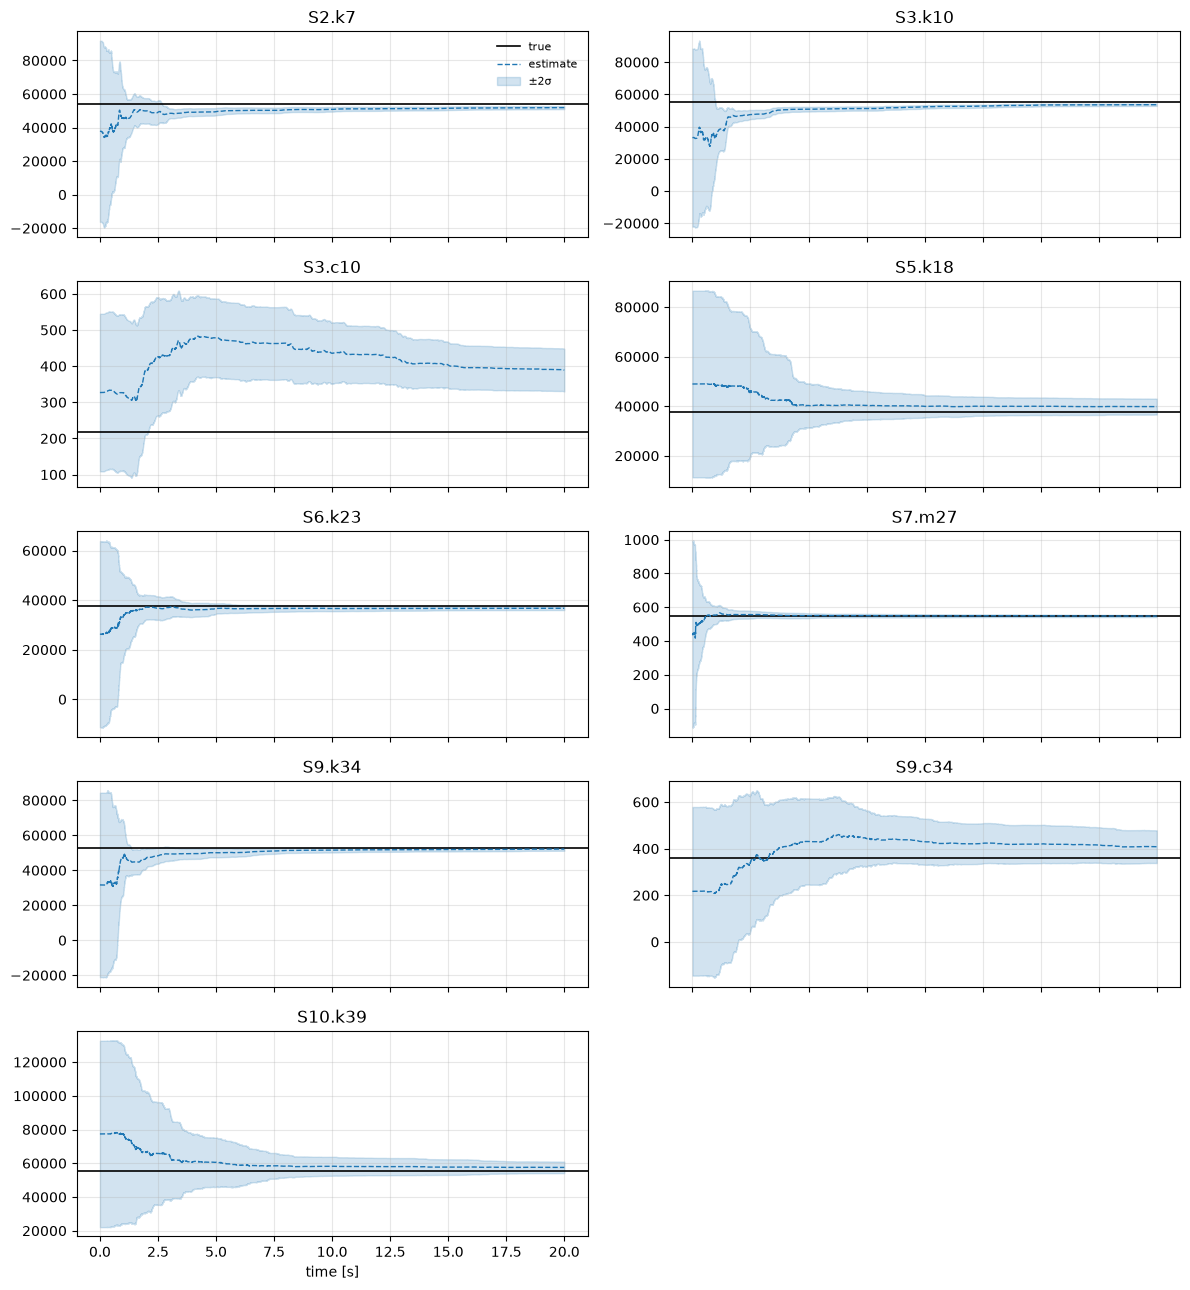

In [5]:
res.plot_parameters();

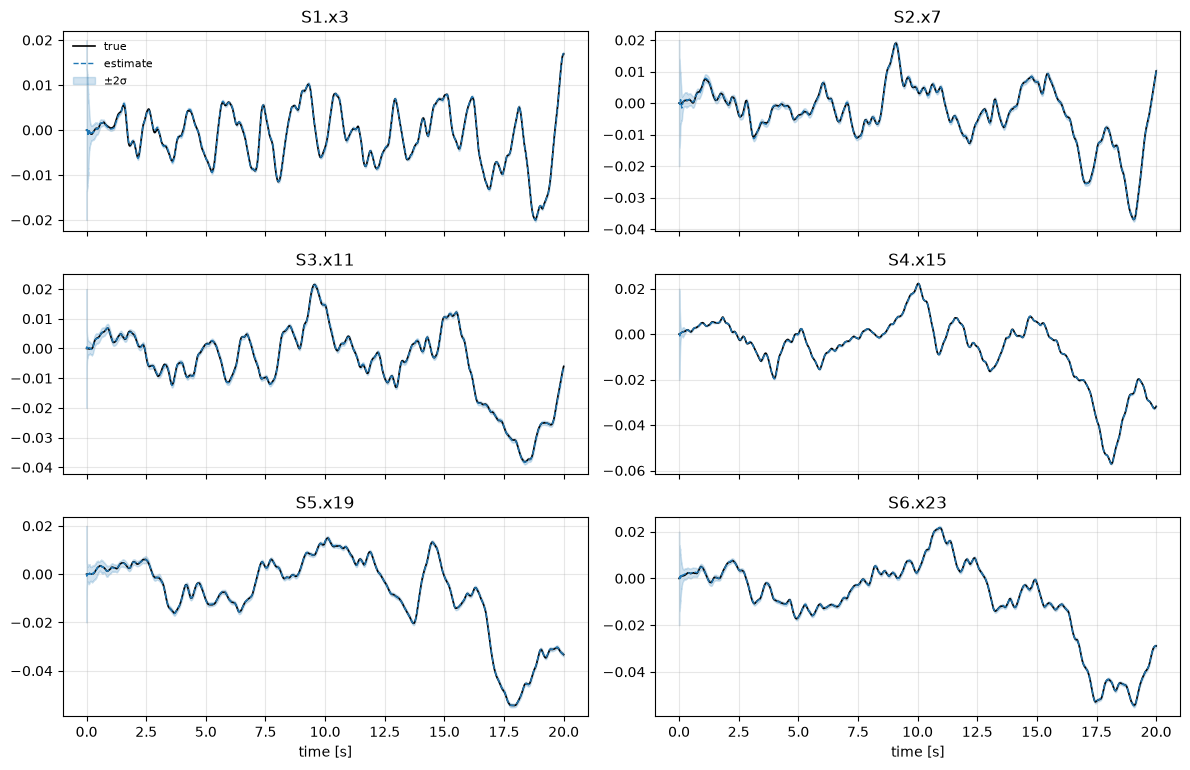

In [6]:
res.plot_states([f"{name}.x{g[len(g) // 2]}" for name, g in zip(NAMES, PARTITION)][:6]);

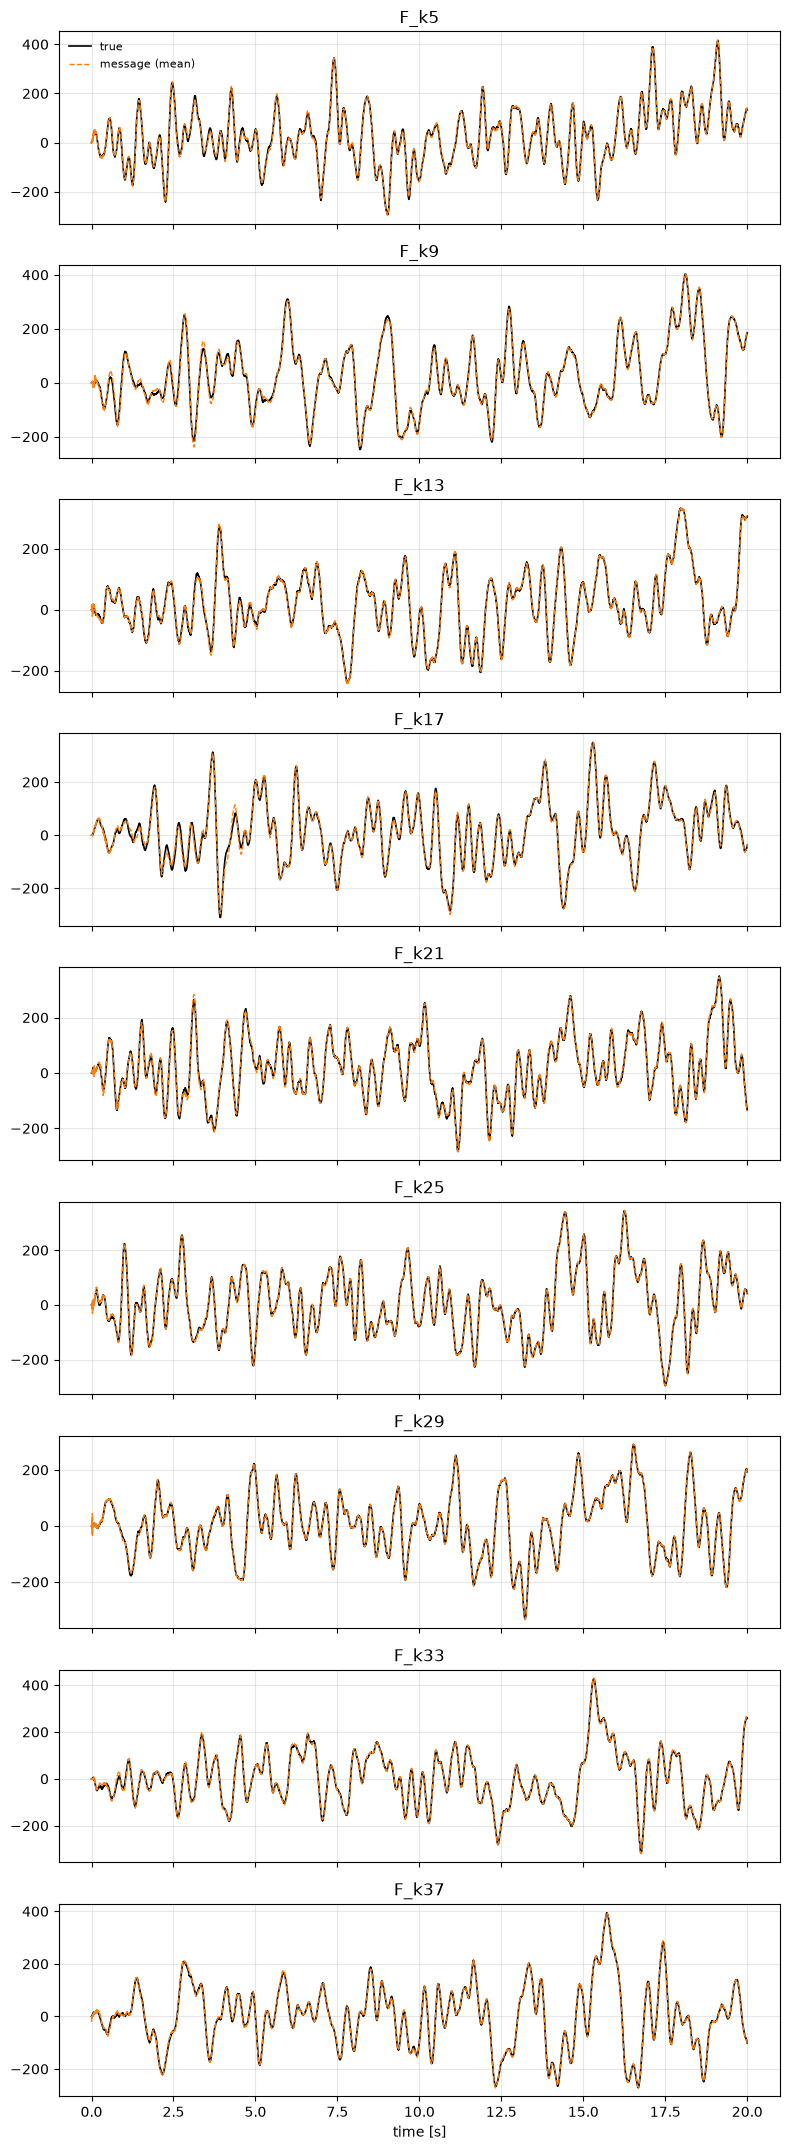

In [7]:
res.plot_messages();

## Centralized comparison (optional)

In [8]:
if RUN_CENTRAL:
    centralized(chain, N_DOF, unknowns, sensors, noise, data, LOADS, DT, T, truth_dict, R_INFLATION, res)

## The YAML twin

`04_case_40dof.yaml` describes the identical problem; with the full 20 s horizon it
reproduces the Python-API result to machine precision.

In [9]:
if T == 20.0:
    compare_with_yaml(res, "04_case_40dof.yaml", unknowns)

YAML twin (04_case_40dof.yaml): k7=51895.5, k10=53597.6, c10=389.0, k18=39840.2, k23=36708.7, m27=547.7, k34=52098.0, c34=408.3, k39=57539.6   max relative difference to Python API: 0.00e+00


Every stiffness and the mass are recovered to within a few percent; dampings identified from single-sensor subsystems remain the weak spot. The cost grows linearly with the number of subsystems, and each subsystem could run on its own core.